# The Digital Sommelier

### Can machine learning pick the better bottle of white wine?

**GOSIM 2026 — Paris**

Fabien Pesquerel & Marie Sacksick · Probabl

---
## Act 1 — The Setup

You're at a restaurant with your boss. Two bottles of white wine
on the menu. No tasting allowed — only the back-label data.

**Can we build a digital sommelier that picks the better bottle?**

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from skrub import tabular_pipeline
from skore import (
    ComparisonReport,
    CrossValidationReport,
    EstimatorReport,
)

In [2]:
# ── Theme: deep blue & orange ────────────────────────────────
DEEP_BLUE = '#0B1D51'
ORANGE    = '#E8600A'
PALETTE = [DEEP_BLUE, ORANGE, '#3A6FB0', '#F2A03D',
           '#1B3A6B', '#C74E00', '#6C9BD2', '#FFB366']
BINARY_COLOURS = {'middle_low': ORANGE, 'top': DEEP_BLUE}
BG_LIGHT = '#FAFBFD'
GRID_COLOUR = '#D5DAE3'

mpl.rcParams.update({
    'figure.facecolor': BG_LIGHT, 'figure.figsize': (12, 5),
    'figure.dpi': 120, 'axes.facecolor': BG_LIGHT,
    'axes.edgecolor': GRID_COLOUR, 'axes.labelcolor': DEEP_BLUE,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.grid': True, 'axes.spines.top': False,
    'axes.spines.right': False, 'grid.color': GRID_COLOUR,
    'grid.alpha': 0.5, 'text.color': DEEP_BLUE,
    'font.size': 11, 'legend.frameon': False,
    'savefig.dpi': 200, 'savefig.bbox': 'tight',
})
sns.set_palette(PALETTE)

In [3]:
# Load the UCI white wine quality dataset
url = (
    'https://archive.ics.uci.edu/ml/'
    'machine-learning-databases/wine-quality/winequality-white.csv'
)
df = pd.read_csv(url, sep=';')
df.columns = df.columns.str.replace(' ', '_').str.lower()

# Build the binary target: quality >= 7 → 'top', else → 'middle_low'
y = pd.Categorical(
    ['top' if q >= 7 else 'middle_low' for q in df['quality']],
    categories=['middle_low', 'top'], ordered=True,
)
X = df.drop(columns=['quality'])

print(f'Dataset: {X.shape[0]} wines, {X.shape[1]} features')
print(f'Top-tier wines: {(y == "top").sum()} ({(y == "top").mean():.1%})')

Dataset: 4898 wines, 11 features
Top-tier wines: 1060 (21.6%)


In [4]:
# Hold out 20% for final evaluation — only training data for CV
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)
print(f'Train: {X_train.shape[0]} wines / Test: {X_test.shape[0]} wines')

Train: 3918 wines / Test: 980 wines


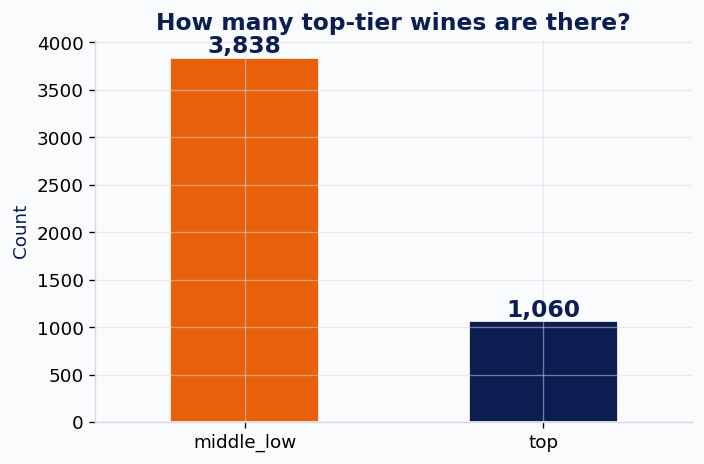

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
pd.Series(y).value_counts().sort_index().plot.bar(
    ax=ax, color=[BINARY_COLOURS['middle_low'], BINARY_COLOURS['top']],
    edgecolor='white',
)
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height()):,}',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom', fontsize=14, fontweight='bold')
ax.set_title('How many top-tier wines are there?', fontweight='bold')
ax.set_xlabel(''), ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
## Act 2 — The Lazy Sommelier

What if our sommelier just says *"they're all mediocre"*?

With 80% of wines being middle-low, always predicting `middle_low`
gives **~80% accuracy**. Impressive? No. Useless.

In [6]:
# The 'lazy sommelier': always predicts middle_low
pipe_dummy = tabular_pipeline(DummyClassifier(strategy='most_frequent'))
report_dummy = CrossValidationReport(
    pipe_dummy, X=X_train, y=y_train, splitter=5, pos_label='top',
)

display = report_dummy.metrics.summarize()
display.frame()

Output()

Output()

/Users/fabien/Documents/Claude/Projects/DevRel python 
projects/wine-data-analysis/.wineenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: 
UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use 
`zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])

/Users/fabien/Documents/Claude/Projects/DevRel python 
projects/wine-data-analysis/.wineenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: 
UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use 
`zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])

/Users/fabien/Documents/Claude/Projects/DevRel python 
projects/wine-data-analysis/.wineenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: 
UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use 
`zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])

/Users/fabien/Documents/Claude/Projects/DevRel python 
projects/wine-data-analysis/.wineenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: 
UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use 
`zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])

/Users/fabien/Documents/Claude/Projects/DevRel python 
projects/wine-data-analysis/.wineenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: 
UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use 
`zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])

DummyClassifier          
                            mean       std
Metric                                    
Accuracy                0.783563  0.000548
Precision               0.000000  0.000000
Recall                  0.000000  0.000000
ROC AUC                 0.500000  0.000000
Log loss                7.801168  0.019746
Brier score             0.216437  0.000548
Fit time (s)            0.012248  0.001737
Predict time (s)        0.005377  0.000162

~80% accuracy, 0 recall, 0.5 AUC. Our lazy sommelier can't
distinguish anything — **accuracy alone is misleading.**

---
## Act 3 — Training Real Sommeliers

Let's train three actual models and evaluate them *properly*
with `skore`.

In [7]:
# Three candidate sommeliers
pipe_gb = tabular_pipeline(
    HistGradientBoostingClassifier(max_iter=200, random_state=42)
)
pipe_rf = tabular_pipeline(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
)
pipe_lr = tabular_pipeline(
    LogisticRegression(max_iter=1000, random_state=42)
)

report_gb = CrossValidationReport(pipe_gb, X=X_train, y=y_train, splitter=5, pos_label='top')
report_rf = CrossValidationReport(pipe_rf, X=X_train, y=y_train, splitter=5, pos_label='top')
report_lr = CrossValidationReport(pipe_lr, X=X_train, y=y_train, splitter=5, pos_label='top')

print('All three sommeliers trained and evaluated.')

Output()

Output()

Output()

All three sommeliers trained and evaluated.


### The Sommelier Showdown

One line of code to compare all candidates side by side.

In [8]:
comparison = ComparisonReport(reports=[report_dummy, report_gb, report_rf, report_lr])

display = comparison.metrics.summarize()
display.frame()

Output()

mean                                 \
Estimator        DummyClassifier HistGradientBoostingClassifier   
Metric                                                            
Accuracy                0.783563                       0.863962   
Precision               0.000000                       0.732667   
Recall                  0.000000                       0.586105   
ROC AUC                 0.500000                       0.896280   
Log loss                7.801168                       0.351192   
Brier score             0.216437                       0.102962   
Fit time (s)            0.012248                       0.496858   
Predict time (s)        0.005377                       0.013813   

                                                                       std  \
Estimator        LogisticRegression RandomForestClassifier DummyClassifier   
Metric                                                                       
Accuracy                   0.799897               0.866769        0.000548   
Precision                  0.583083               0.793791        0.000000   
Recall                     0.279520               0.522450        0.000000   
ROC AUC                    0.797834               0.905654        0.000000   
Log loss                   0.420733               0.306613        0.019746   
Brier score                0.134337               0.095043        0.000548   
Fit time (s)               0.016170               0.156653        0.001737   
Predict time (s)           0.005477               0.031544        0.000162   

                                                                    \
Estimator        HistGradientBoostingClassifier LogisticRegression   
Metric                                                               
Accuracy                               0.004368           0.008052   
Precision                              0.020177           0.049630   
Recall                                 0.023627           0.020051   
ROC AUC                                0.010123           0.026899   
Log loss                               0.018316           0.018764   
Brier score                            0.003760           0.005456   
Fit time (s)                           0.028764           0.000876   
Predict time (s)                       0.001813           0.000095   

                                         
Estimator        RandomForestClassifier  
Metric                                   
Accuracy                       0.007474  
Precision                      0.041249  
Recall                         0.035280  
ROC AUC                        0.008686  
Log loss                       0.009128  
Brier score                    0.003409  
Fit time (s)                   0.006384  
Predict time (s)               0.000756

### Why AUC matters more than accuracy here

At the restaurant, you're not classifying every wine in the world.
You're choosing **between two bottles** — you need the model that
**ranks** a top wine higher than a mediocre one.

That's exactly what AUC measures: *the probability that the model
ranks a random top wine above a random middle-low wine.*

Accuracy asks: "how often are you right?"
AUC asks: **"can you tell the difference?"**

A good sommelier doesn't need to score every wine perfectly —
they need to reliably pick the better bottle.

Output()

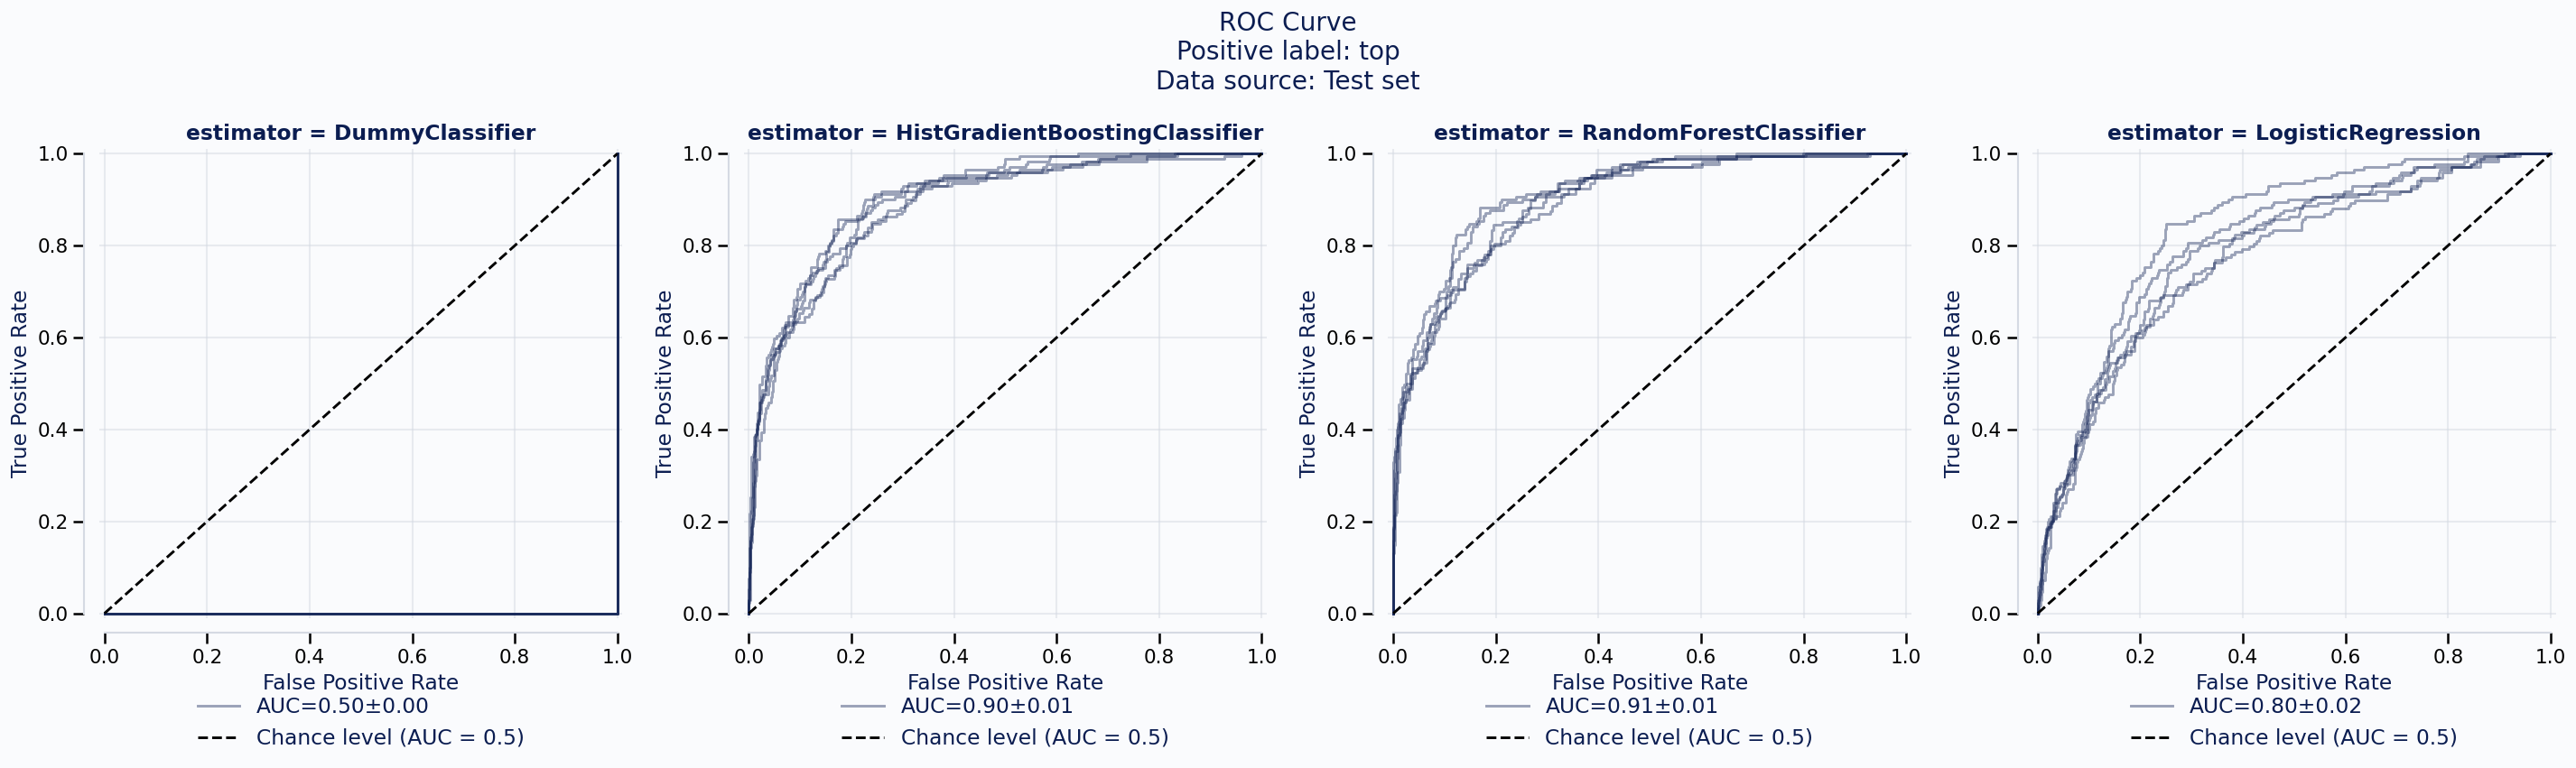

In [9]:
display = comparison.metrics.roc()
display.plot()

### Quality control — `diagnose()`

Before trusting any sommelier, let's check for red flags.
`skore.diagnose()` catches overfitting, underfitting, and other
methodological issues — **automatically.**

In [10]:
for name, report in [
    ('Gradient Boosting', report_gb),
    ('Random Forest', report_rf),
    ('Logistic Regression', report_lr),
]:
    diag = report.diagnose()
    n_issues = len(diag.issues)
    status = '✅ healthy' if n_issues == 0 else f'⚠️ {n_issues} issue(s)'
    print(f'{name}: {status}')
    if n_issues > 0:
        for code_id, issue in diag.issues.items():
            print(f"    {code_id}: {issue['title']}")

Gradient Boosting: ⚠️ 1 issue(s)
    SKD001: Potential overfitting
Random Forest: ⚠️ 1 issue(s)
    SKD001: Potential overfitting
Logistic Regression: ✅ healthy


A sommelier who memorized the wine list instead of learning
about wine? That's overfitting. `diagnose()` catches it before
you deploy the model — **detecting problems early is cheaper
than fixing them late.**

---
## Act 4 — Finding the Best Sommelier

One model isn't enough. Let's systematically explore the
hyperparameter space for **all three model families**, keep only
the configurations that pass `diagnose()`, and push the healthy
ones to the **skore hub** for team review.

In [11]:
import skore
from itertools import product

skore.login(mode='hub')

print('Logged in to skore hub.')

Output()

Logged in to skore hub.


### Random Forest — 80 configurations

In [12]:
n_estimators_range = [10, 30, 50, 100]
max_depth_range = [2, 4, 6, 8, 10]
min_samples_leaf_range = [5, 20, 40, 70]

rf_reports = {}
for n_est, depth, leaf in product(
    n_estimators_range, max_depth_range, min_samples_leaf_range,
):
    name = f'RF (n={n_est}, d={depth}, leaf={leaf})'
    pipe = tabular_pipeline(
        RandomForestClassifier(
            n_estimators=n_est, max_depth=depth,
            min_samples_leaf=leaf, random_state=42, n_jobs=-1,
        )
    )
    report = CrossValidationReport(pipe, X=X_train, y=y_train, splitter=5, pos_label='top')
    rf_reports[name] = report

print(f'{len(rf_reports)} RF configurations trained.')

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

80 RF configurations trained.


In [13]:
# Filter healthy RF models, create EstimatorReports, push to hub
rf_healthy = {
    name: r for name, r in rf_reports.items()
    if len(r.diagnose().issues) == 0
}
print(f'Healthy: {len(rf_healthy)} / {len(rf_reports)}')

project_rf = skore.Project(name='gosim/digital-sommelier-rf', mode='hub')
for name, cv_report in rf_healthy.items():
    pipe = clone(cv_report.estimator)
    pipe.fit(X_train, y_train)
    er = EstimatorReport(
        pipe, X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test, pos_label='top',
    )
    project_rf.put(name, er)

print(f'{len(rf_healthy)} healthy RF EstimatorReports pushed to gosim/digital-sommelier-rf')

Healthy: 72 / 80


Output()

Consult your report at 
]8;id=1698456;https://skore.probabl.ai/gosim/digital-sommelier-rf/estimators/11214\https://skore.probabl.ai/gosim/digital-sommelier-rf/estimators/11214]8;;\

Output()

Consult your report at 
]8;id=1698459;https://skore.probabl.ai/gosim/digital-sommelier-rf/estimators/11215\https://skore.probabl.ai/gosim/digital-sommelier-rf/estimators/11215]8;;\

...

Output()

Consult your report at 
]8;id=1698666;https://skore.probabl.ai/gosim/digital-sommelier-rf/estimators/11284\https://skore.probabl.ai/gosim/digital-sommelier-rf/estimators/11284]8;;\

Output()

Consult your report at 
]8;id=1698669;https://skore.probabl.ai/gosim/digital-sommelier-rf/estimators/11285\https://skore.probabl.ai/gosim/digital-sommelier-rf/estimators/11285]8;;\

72 healthy RF EstimatorReports pushed to gosim/digital-sommelier-rf


### Logistic Regression — 100 configurations

In [14]:
C_values = np.logspace(-4, 2, 100)

lr_reports = {}
for c_val in C_values:
    name = f'LR (C={c_val:.6f})'
    pipe = tabular_pipeline(
        LogisticRegression(
            C=c_val, penalty='l2', max_iter=1000, random_state=42,
        )
    )
    report = CrossValidationReport(pipe, X=X_train, y=y_train, splitter=5, pos_label='top')
    lr_reports[name] = report

print(f'{len(lr_reports)} LR configurations trained.')

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

100 LR configurations trained.


In [15]:
# Filter healthy LR models, create EstimatorReports, push to hub
lr_healthy = {
    name: r for name, r in lr_reports.items()
    if len(r.diagnose().issues) == 0
}
print(f'Healthy: {len(lr_healthy)} / {len(lr_reports)}')

project_lr = skore.Project(name='gosim/digital-sommelier-lr', mode='hub')
for name, cv_report in lr_healthy.items():
    pipe = clone(cv_report.estimator)
    pipe.fit(X_train, y_train)
    er = EstimatorReport(
        pipe, X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test, pos_label='top',
    )
    project_lr.put(name, er)

print(f'{len(lr_healthy)} healthy LR EstimatorReports pushed to gosim/digital-sommelier-lr')

Healthy: 89 / 100


Output()

Consult your report at 
]8;id=1698672;https://skore.probabl.ai/gosim/digital-sommelier-lr/estimators/11286\https://skore.probabl.ai/gosim/digital-sommelier-lr/estimators/11286]8;;\

Output()

Consult your report at 
]8;id=1698675;https://skore.probabl.ai/gosim/digital-sommelier-lr/estimators/11287\https://skore.probabl.ai/gosim/digital-sommelier-lr/estimators/11287]8;;\

...

Output()

Consult your report at 
]8;id=1698933;https://skore.probabl.ai/gosim/digital-sommelier-lr/estimators/11373\https://skore.probabl.ai/gosim/digital-sommelier-lr/estimators/11373]8;;\

Output()

Consult your report at 
]8;id=1698936;https://skore.probabl.ai/gosim/digital-sommelier-lr/estimators/11374\https://skore.probabl.ai/gosim/digital-sommelier-lr/estimators/11374]8;;\

89 healthy LR EstimatorReports pushed to gosim/digital-sommelier-lr


### Gradient Boosting — 200 configurations

In [16]:
gb_max_depth_range = [2, 4, 6, 8, 10]
gb_min_samples_leaf_range = [5, 20, 40, 70]
gb_l2_values = np.concatenate([[0], np.logspace(-2, 2, 9)])

gb_reports = {}
for depth in gb_max_depth_range:
    for leaf in gb_min_samples_leaf_range:
        for l2 in gb_l2_values:
            name = f'GB (d={depth}, leaf={leaf}, l2={l2:.4f})'
            pipe = tabular_pipeline(
                HistGradientBoostingClassifier(
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    l2_regularization=l2,
                    max_iter=200,
                    random_state=42,
                )
            )
            report = CrossValidationReport(
                pipe, X=X_train, y=y_train, splitter=5, pos_label='top',
            )
            gb_reports[name] = report

print(f'{len(gb_reports)} GB configurations trained.')

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

200 GB configurations trained.


In [17]:
# Filter healthy GB models, create EstimatorReports, push to hub
gb_healthy = {
    name: r for name, r in gb_reports.items()
    if len(r.diagnose().issues) == 0
}
print(f'Healthy: {len(gb_healthy)} / {len(gb_reports)}')

project_gb = skore.Project(name='gosim/digital-sommelier-gb', mode='hub')
for name, cv_report in gb_healthy.items():
    pipe = clone(cv_report.estimator)
    pipe.fit(X_train, y_train)
    er = EstimatorReport(
        pipe, X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test, pos_label='top',
    )
    project_gb.put(name, er)

print(f'{len(gb_healthy)} healthy GB EstimatorReports pushed to gosim/digital-sommelier-gb')

Healthy: 45 / 200


Output()

Consult your report at 
]8;id=1698939;https://skore.probabl.ai/gosim/digital-sommelier-gb/estimators/11375\https://skore.probabl.ai/gosim/digital-sommelier-gb/estimators/11375]8;;\

Output()

Consult your report at 
]8;id=1698942;https://skore.probabl.ai/gosim/digital-sommelier-gb/estimators/11376\https://skore.probabl.ai/gosim/digital-sommelier-gb/estimators/11376]8;;\

...

Output()

Consult your report at 
]8;id=1699068;https://skore.probabl.ai/gosim/digital-sommelier-gb/estimators/11418\https://skore.probabl.ai/gosim/digital-sommelier-gb/estimators/11418]8;;\

Output()

Consult your report at 
]8;id=1699071;https://skore.probabl.ai/gosim/digital-sommelier-gb/estimators/11419\https://skore.probabl.ai/gosim/digital-sommelier-gb/estimators/11419]8;;\

45 healthy GB EstimatorReports pushed to gosim/digital-sommelier-gb


### Summary

**380 candidates** (80 RF + 100 LR + 200 GB) → filtered by
`diagnose()` → healthy `EstimatorReport`s pushed to the
**skore hub**.

This is what `skore` enables: *rigorous model selection,
programmatically.* No guesswork, no manual checking — the
scientific guardrails are built into the workflow.

Now go to the hub, review the reports, and pick the best
sommelier from each family. Paste the report names below.

In [19]:
# ── Select your best models from the hub ──────────────────────
# After reviewing reports on the hub, paste the report names here.
selected_names = [
    'RF (n=10, d=10, leaf=20)', 'RF (n=30, d=10, leaf=20)', 'RF (n=100, d=10, leaf=20)', 'RF (n=50, d=10, leaf=20)',
    'LR (C=0.011498)', 'LR (C=0.035112)', 'LR (C=0.123285)',
    'GB (d=4, leaf=70, l2=31.6228)',
]

# Build curated EstimatorReports from the healthy CV reports
all_healthy = {}
all_healthy.update(rf_healthy)
all_healthy.update(lr_healthy)
all_healthy.update(gb_healthy)

best_reports = {}
for name in selected_names:
    cv_report = all_healthy[name]
    pipe = clone(cv_report.estimator)
    pipe.fit(X_train, y_train)
    er = EstimatorReport(
        pipe, X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test, pos_label='top',
    )
    best_reports[name] = er
    print(f'  ✓ {name}')

print(f'\n{len(best_reports)} best EstimatorReports created.')

  ✓ RF (n=10, d=10, leaf=20)
  ✓ RF (n=30, d=10, leaf=20)
  ✓ RF (n=100, d=10, leaf=20)
  ✓ RF (n=50, d=10, leaf=20)
  ✓ LR (C=0.011498)
  ✓ LR (C=0.035112)
  ✓ LR (C=0.123285)
  ✓ GB (d=4, leaf=70, l2=31.6228)

8 best EstimatorReports created.


In [20]:
# Push curated best reports to a dedicated hub project
project_final = skore.Project(
    name='gosim/digital-sommelier-final', mode='hub',
)
for name, report in best_reports.items():
    project_final.put(name, report)
    print(f'  ✓ {name}  →  gosim/digital-sommelier-final')

print(f'\n{len(best_reports)} curated reports pushed for final selection.')

Output()

Consult your report at 
]8;id=1699074;https://skore.probabl.ai/gosim/digital-sommelier-final/estimators/11420\https://skore.probabl.ai/gosim/digital-sommelier-final/estimators/11420]8;;\

Output()

  ✓ RF (n=10, d=10, leaf=20)  →  gosim/digital-sommelier-final


Consult your report at 
]8;id=1699077;https://skore.probabl.ai/gosim/digital-sommelier-final/estimators/11421\https://skore.probabl.ai/gosim/digital-sommelier-final/estimators/11421]8;;\

...

Consult your report at 
]8;id=1699092;https://skore.probabl.ai/gosim/digital-sommelier-final/estimators/11426\https://skore.probabl.ai/gosim/digital-sommelier-final/estimators/11426]8;;\

Output()

  ✓ LR (C=0.123285)  →  gosim/digital-sommelier-final


Consult your report at 
]8;id=1699095;https://skore.probabl.ai/gosim/digital-sommelier-final/estimators/11427\https://skore.probabl.ai/gosim/digital-sommelier-final/estimators/11427]8;;\

  ✓ GB (d=4, leaf=70, l2=31.6228)  →  gosim/digital-sommelier-final

8 curated reports pushed for final selection.


---
## Act 5 — The Wine Cellar (skore hub)

Our curated best models are now on the hub in a dedicated
project. Go review them side by side, and pick **one final
sommelier**. Paste the report name below.

In [22]:
# ── Paste the name of your final best model here ──────────────
final_model_name = 'GB (d=4, leaf=70, l2=31.6228)'

final_report = best_reports[final_model_name]
print(f'Final sommelier: {final_model_name}')

Final sommelier: GB (d=4, leaf=70, l2=31.6228)


---
## Act 6 — What Does a Good Sommelier Look For?

Now that we have our final sommelier, let's understand *how*
it makes its decisions.

Two perspectives: what the **data** says matters (correlation),
and what the **best model** actually uses (permutation importance).

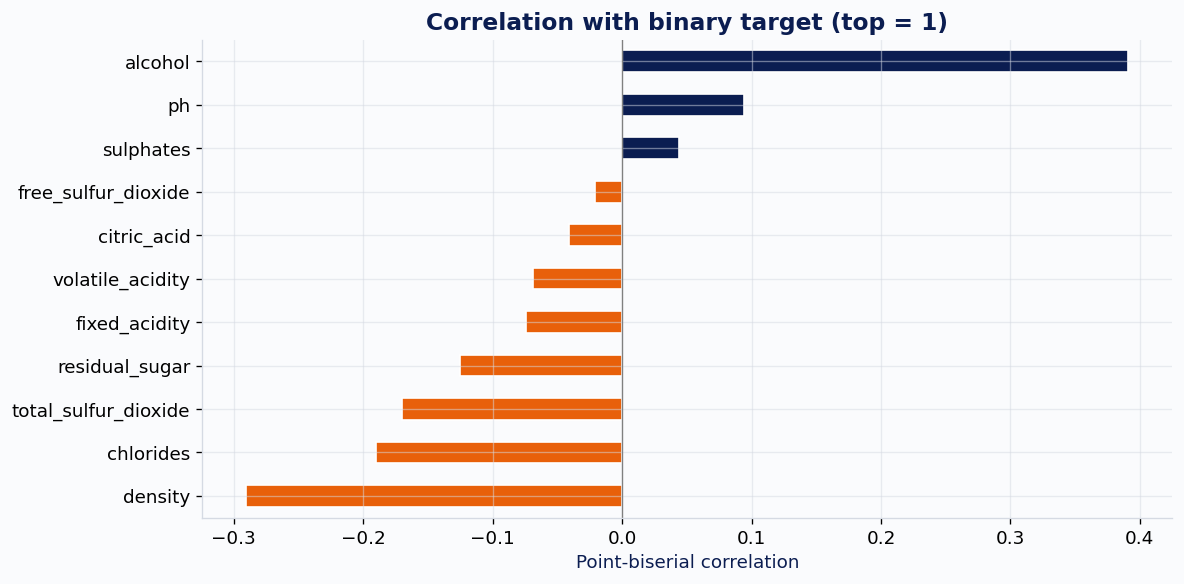

In [23]:
# What the DATA says: correlation with 'top' vs 'middle_low'
y_numeric = pd.Series((y_train == 'top').astype(int), index=X_train.index)
correlations = X_train.corrwith(y_numeric).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = [DEEP_BLUE if v >= 0 else ORANGE for v in correlations.values]
correlations.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.set_title('Correlation with binary target (top = 1)', fontweight='bold')
ax.set_xlabel('Point-biserial correlation')
ax.axvline(0, color='grey', linewidth=0.8)
plt.tight_layout()
plt.show()

### What does our best sommelier actually use?

Permutation importance on the **final selected model** reveals
which features it actually relies on — and how that differs
from raw correlations.

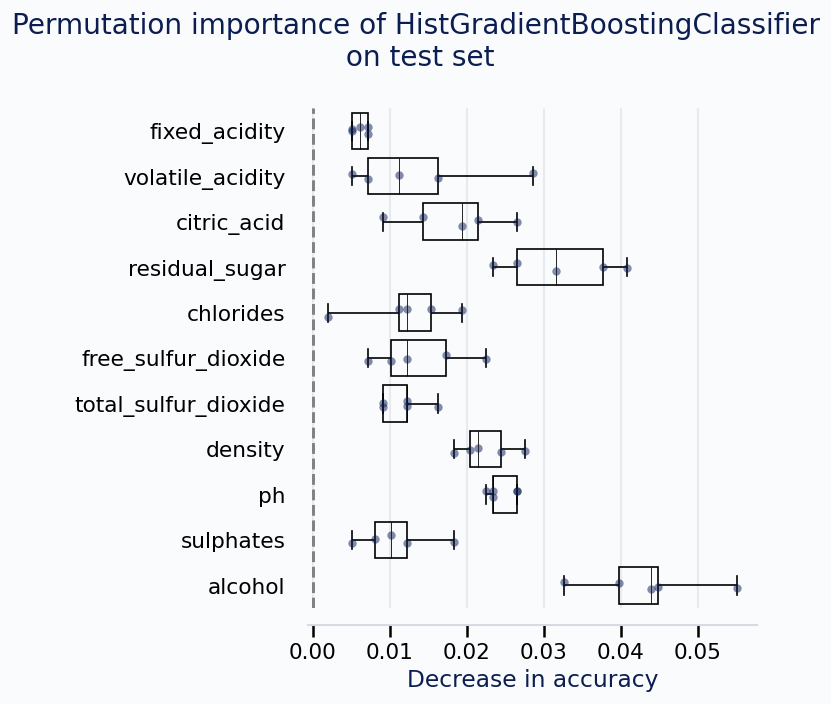

In [24]:
display = final_report.inspection.permutation_importance()
display.plot()

The best model doesn't just follow correlations — it discovers
non-linear patterns the data scientist might miss.

**This is why interpretation matters, and why we interpret
the final, curated model — not the first one we trained.**

Every `EstimatorReport` on the hub carries the full scientific
context: metrics, ROC curves, confusion matrices, permutation
importance. Your team lead can review your work **without
re-running a single cell.**

---
## Act 7 — The AI Sommelier Assistant

AI tools like Claude can generate code fast. But speed without
scientific rigour means you fool yourself faster.

**skore + AI = fast *and* rigorous.**

skore's clean, structured API makes it naturally AI-friendly.
Let's see this in action...

*(live demo with Claude)*

---
## Closing

### What we built today

A **digital sommelier** — trained on physicochemical data,
evaluated with scientific rigour, and shared with the team.

### What skore gives you

- **`CrossValidationReport`** — proper evaluation, not just accuracy
- **`ComparisonReport`** — side-by-side comparison in one line
- **`diagnose()`** — catch overfitting before it catches you
- **Permutation importance** — understand *what* your model learned
- **The hub** — experiment tracking designed for data *science*

### The takeaway

The tools to do data science *fast* already exist.
**skore** is the tool to do data science *right.*

---

### 🍷 Want to test your own sommelier skills?

Join us tonight at **La Felicità** for a glass of wine!

---

**probabl.ai** · **github.com/probabl-ai/skore**